In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
main_path = os.getcwd()
import sys
sys.path.append(main_path)

from analysis.libraries.survival import plot_km_two_groups

In [2]:
tcga_data = pd.read_csv(os.path.join(main_path, 'data/results/joint_mki67_t_frame.csv'))
tcga_data

,Unnamed: 0,samples,MKI67,high_mki67,OS.time,OS,OS.time.mo,T cells,high_t
0,1,TCGA-05-4249,3.259694,0,1523,0,50.071233,2.264366,0
1,2,TCGA-05-4250,4.956238,1,121,1,3.978082,2.545644,1
2,3,TCGA-05-4382,3.523988,0,607,0,19.956164,2.388044,1
3,4,TCGA-05-4384,2.537818,0,426,0,14.005479,1.970764,0
4,5,TCGA-05-4389,4.037356,1,1369,0,45.008219,2.972676,1
...,...,...,...,...,...,...,...,...,...
499,500,TCGA-NJ-A55O,3.418568,0,13,0,0.427397,1.949938,0
500,501,TCGA-NJ-A55R,3.586140,0,603,0,19.824658,1.718955,0
501,502,TCGA-NJ-A7XG,2.096565,0,617,0,20.284932,1.395849,0
502,503,TCGA-O1-A52J,3.482448,0,1798,1,59.112329,2.099382,0


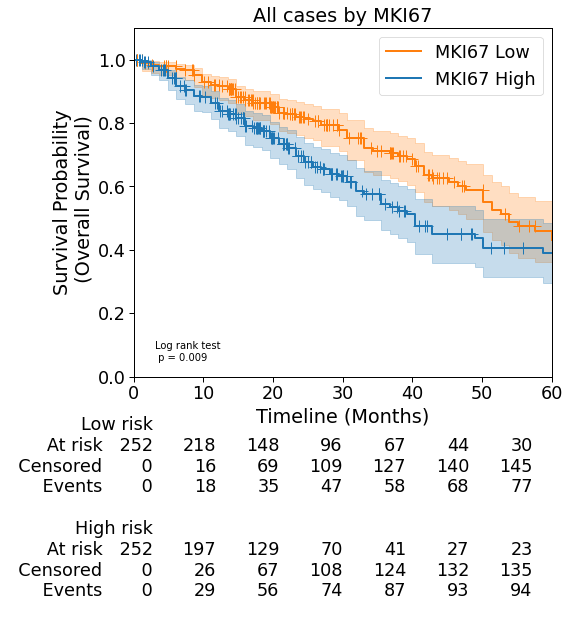

In [3]:
sns.set_context("paper", font_scale=2.0)
fig, ax = plt.subplots(figsize=(8,9))

plot_km_two_groups(df=tcga_data, 
                   event_ind_field='OS', 
                   event_data_field='OS.time.mo', 
                   group_col='high_mki67', 
                   max_months=60, 
                   add_counts=True, 
                   title='All cases by MKI67', 
                   ci_show=True, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'MKI67 Low', f'MKI67 High'])  



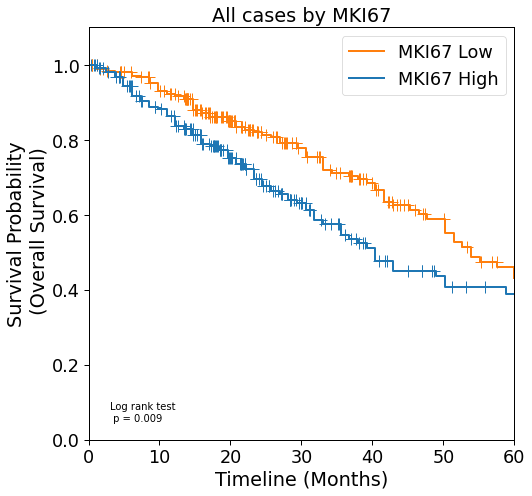

In [4]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=tcga_data, 
                   event_ind_field='OS', 
                   event_data_field='OS.time.mo', 
                   group_col='high_mki67', 
                   max_months=60, 
                   add_counts=False, 
                   title='All cases by MKI67', 
                   ci_show=False, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'MKI67 Low', f'MKI67 High'])  



In [5]:
tcga_data.columns

Index(['Unnamed: 0', 'samples', 'MKI67', 'high_mki67', 'OS.time', 'OS',
       'OS.time.mo', 'T cells', 'high_t'],
      dtype='object')

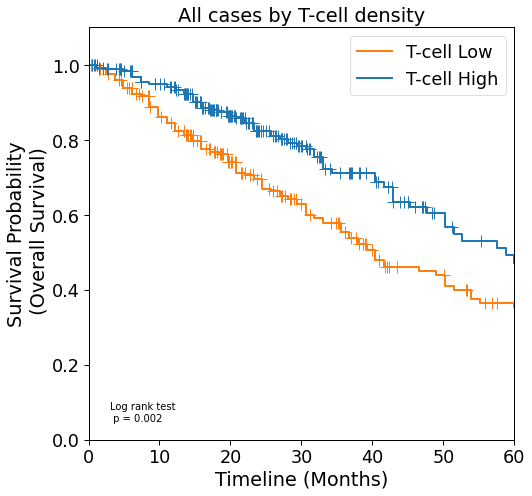

In [6]:
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=tcga_data, 
                   event_ind_field='OS', 
                   event_data_field='OS.time.mo', 
                   group_col='high_t', 
                   max_months=60, 
                   add_counts=False, 
                   title='All cases by T-cell density', 
                   ci_show=False, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  

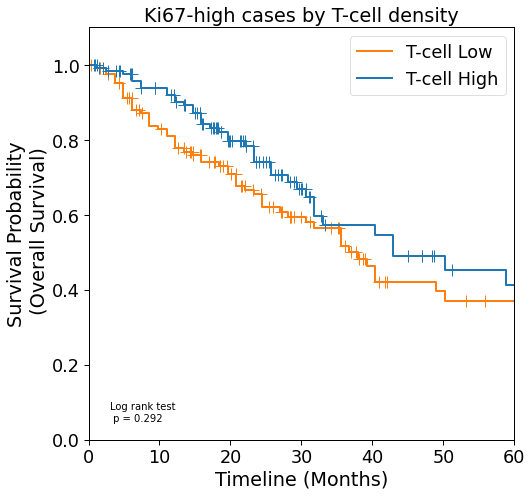

In [7]:
low_ki67 = tcga_data[tcga_data['high_mki67'] == 1]
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=low_ki67, 
                   event_ind_field='OS', 
                   event_data_field='OS.time.mo', 
                   group_col='high_t', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-high cases by T-cell density', 
                   ci_show=False, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  


In [8]:
low_ki67['high_t'].value_counts()

0    129
1    123
Name: high_t, dtype: int64

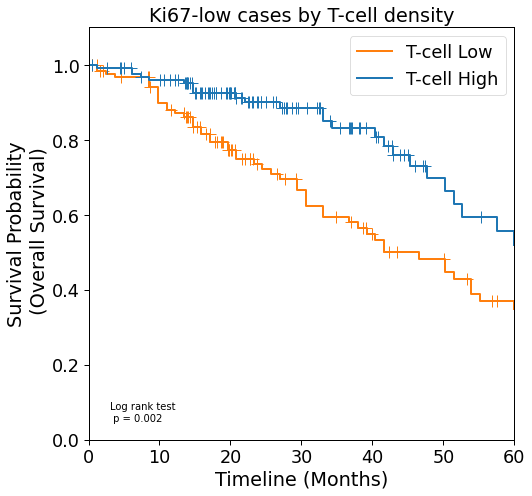

In [9]:
high_ki67 = tcga_data[tcga_data['high_mki67'] == 0]
fig, ax = plt.subplots(figsize=(7.5,7))

plot_km_two_groups(df=high_ki67, 
                   event_ind_field='OS', 
                   event_data_field='OS.time.mo', 
                   group_col='high_t', 
                   max_months=60, 
                   add_counts=False, 
                   title='Ki67-low cases by T-cell density', 
                   ci_show=False, 
                   ax=ax)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [f'T-cell Low', f'T-cell High'])  



In [10]:
high_ki67['high_t'].value_counts()

1    129
0    123
Name: high_t, dtype: int64